In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as sct

In [ ]:
df =sns.load_dataset("healthexp")
df
#descrit variables : [life_expectancy]
#Continuous variables : [spendig_USD], []

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


#Analyze the "Country" variable.

In [ ]:
df['Country'].value_counts() # count haw many times every singl vules repet

Country
USA              51
Japan            51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

In [ ]:

df['Country'].isnull().sum() # detect null values

np.int64(0)

Text(0.5, 1.0, 'count of countrys')

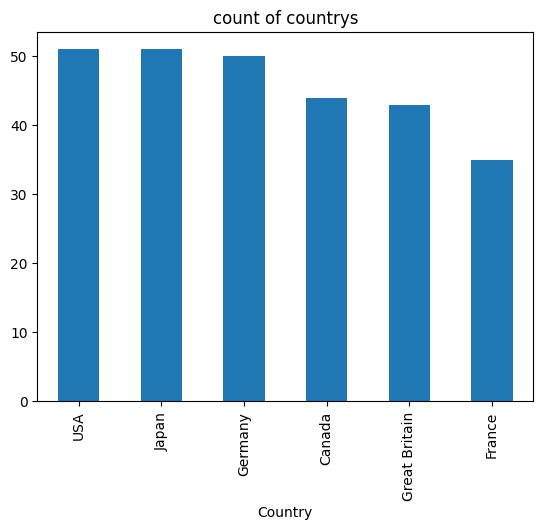

In [ ]:
plt.Figure()
df['Country'].value_counts().plot.bar()
plt.title("count of countrys", c = 'k')

#Analyze the variable "Spending _USD".


In [ ]:
# ----analyse the [spending_USD] variable

df['Spending_USD'].describe() # describe the variable

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

In [ ]:
df['Spending_USD'].sum() # sum of values

np.float64(764278.86)

#Create the two graphs needed for this analysis.

<Axes: xlabel='Spending_USD', ylabel='Count'>

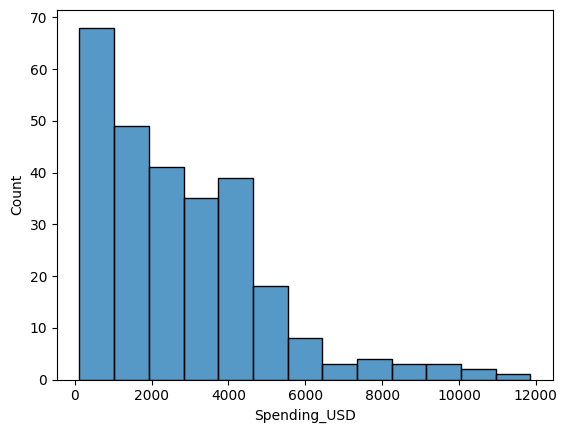

In [ ]:
plt.Figure()
sns.histplot(data=df, x =  df['Spending_USD'])

<Axes: xlabel='Spending_USD'>

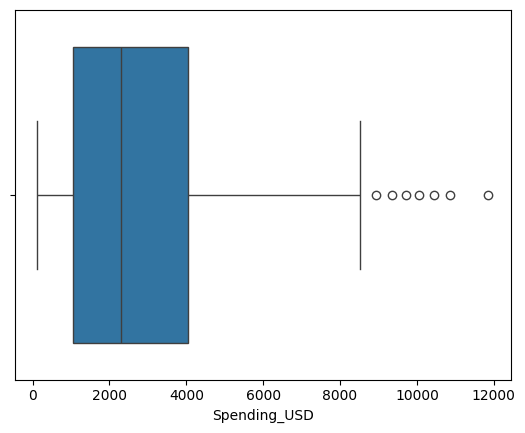

In [ ]:
plt.Figure()
sns.boxplot(data=df, x = df['Spending_USD'])

Do the same for the "Life_Expectancy " variable.

In [ ]:
# ----analyse life expectancy variable
df['Life_Expectancy'].describe()

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64

In [ ]:
#detect null values
df['Life_Expectancy'].isnull().sum()

np.int64(0)

<Axes: xlabel='Life_Expectancy', ylabel='Count'>

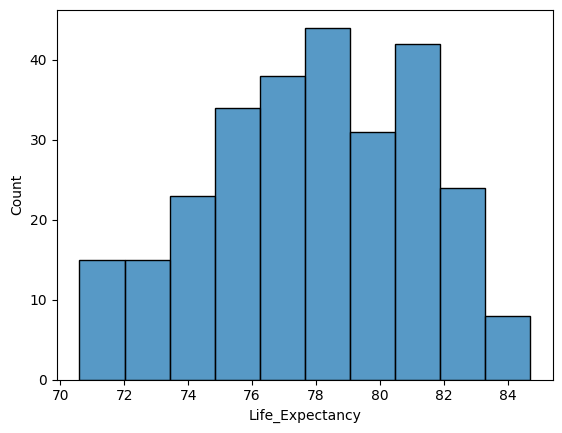

In [ ]:
plt.Figure()
sns.histplot(data = df, x = df['Life_Expectancy'])

<Axes: xlabel='Life_Expectancy'>

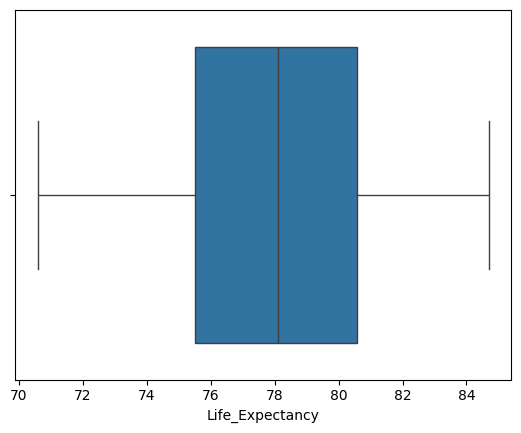

In [ ]:
plt.figure()
sns.boxplot(data = df, x = df['Life_Expectancy'])

Observe how lifespan changes over time.

Text(0.5, 1.0, 'life expectancy over time')

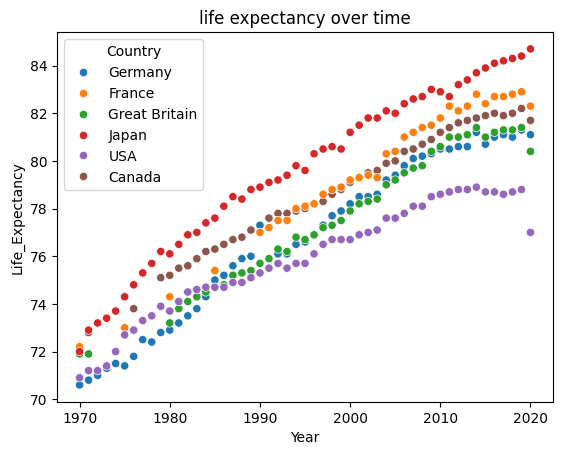

In [ ]:
#life expectancy change over time

sns.scatterplot(x = df['Year'], y = df['Life_Expectancy'], hue = 'Country', data = df)
plt.title("life expectancy over time", c= 'k')


Observe the evolution of health spending in Germany and Great Britain over time.

In [ ]:
# filtring the data frame by country

df_filtered = df.query('Country in ["Germany", "Great Britain"]')
df_filtered

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
2,1970,Great Britain,123.993,71.9
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
10,1972,Germany,337.364,71.0
...,...,...,...,...
259,2018,Great Britain,4189.708,81.3
263,2019,Germany,6407.928,81.3
265,2019,Great Britain,4385.463,81.4
269,2020,Germany,6938.983,81.1


Text(0.5, 1.0, ' evolution of health spending in Germany VS Great Britain over time')

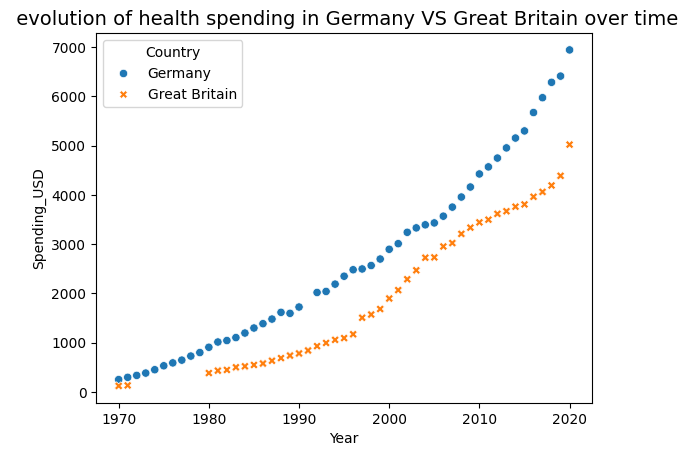

In [ ]:
#analys the evolution of health spending in Germany and Great britain over time using seaborn
#df_filtered = df.query("Country = 'Germany")
sns.scatterplot( 
    x = df_filtered['Year'],
    y = df_filtered['Spending_USD'],
    hue=df_filtered['Country'],
    style = df_filtered['Country'],
    data= df_filtered)
plt.title(" evolution of health spending in Germany VS Great Britain over time", c = 'k', fontsize = 14)


Observe the histogram, the boxplot, and the "Life Expectancy" statistics specific to each country.


<Axes: xlabel='Life_Expectancy', ylabel='Count'>

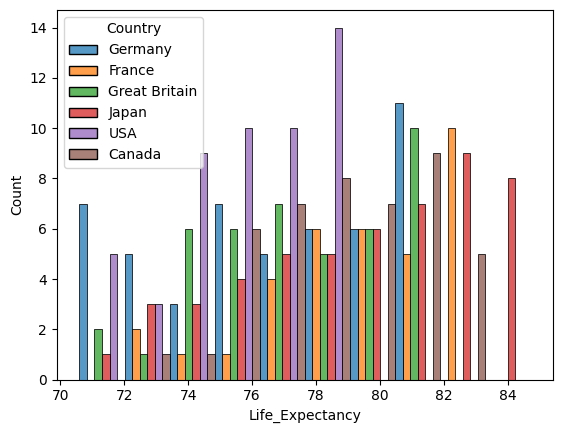

In [ ]:
# Use 'dodge' to see the bars side-by-side
sns.histplot(data=df, x='Life_Expectancy', hue='Country', multiple='dodge')

<Axes: xlabel='Life_Expectancy', ylabel='Country'>

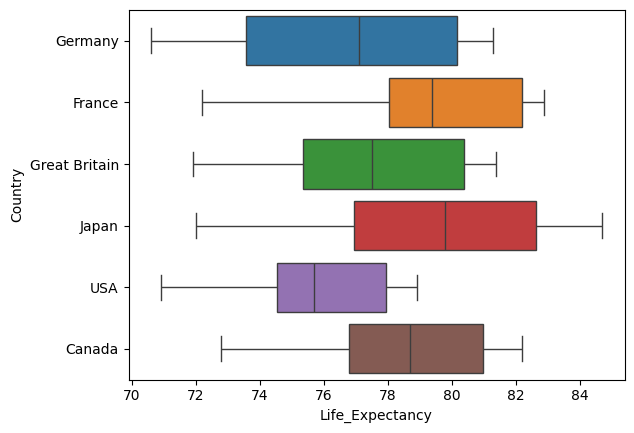

In [ ]:
#boxplot represant the life expactency by country

sns.boxplot(data = df, x =df['Life_Expectancy'], y =  df['Country'], hue='Country')

Observe the relationship between life expectancy and healthcare spending in the United States from 2000 to 2020.

In [ ]:
df_USA = df[(df['Country'] == "USA") & (df['Year'] >= 2000) & (df['Year'] <= 2020)]
df_USA

,Year,Country,Spending_USD,Life_Expectancy
153,2000,USA,4536.561,76.7
159,2001,USA,4888.518,76.9
165,2002,USA,5316.522,77.0
171,2003,USA,5726.538,77.1
177,2004,USA,6069.530,77.6
183,2005,USA,6430.757,77.6
189,2006,USA,6808.054,77.8
195,2007,USA,7166.513,78.1
201,2008,USA,7385.026,78.1
207,2009,USA,7645.002,78.5


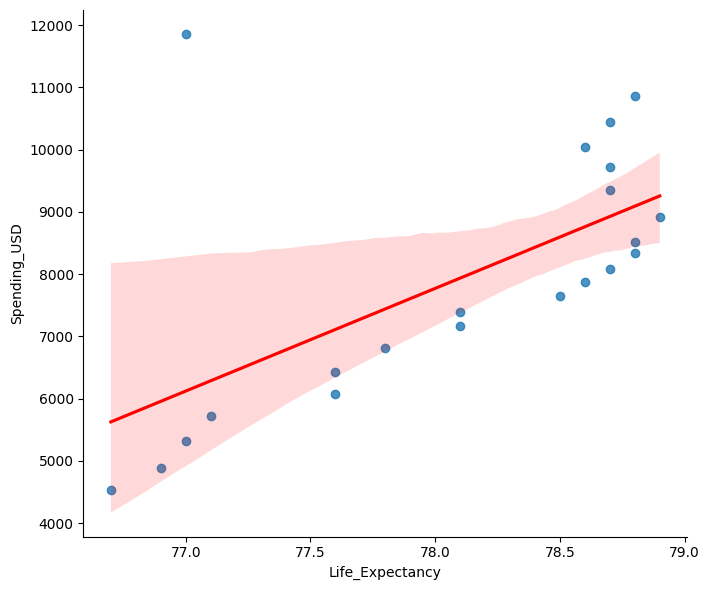

In [ ]:

sns.lmplot(data = df_USA,
        x = 'Life_Expectancy', 
        y = 'Spending_USD',
        height=6, 
        aspect=1.2, 
        line_kws={'color' : 'red'})

In [ ]:
Descriptive_Statistics = [
            df_USA['Life_Expectancy'].mean(),
            df_USA['Life_Expectancy'].median(),
            df_USA['Life_Expectancy'].mode()]
Descriptive_Statistics


[np.float64(78.08095238095238),
 np.float64(78.5),
 0    78.7
 Name: Life_Expectancy, dtype: float64]

In [ ]:
Measures_of_Dispersion = [
            df['Life_Expectancy'].std(),
            df['Life_Expectancy'].var(),
            df['Life_Expectancy'].max() - df['Life_Expectancy'].mean(),
            df_USA['Life_Expectancy'].quantile(0.75) - df_USA['Life_Expectancy'].quantile(0.25)]
Measures_of_Dispersion

[np.float64(3.276263466523638),
 np.float64(10.733902302077485),
 np.float64(6.790510948905123),
 np.float64(1.1000000000000085)]

In [ ]:
Shape_of_Data = [
            df_USA['Life_Expectancy'].skew(),
            df_USA['Life_Expectancy'].kurt()
        ]
Shape_of_Data

[np.float64(-0.6280860072951934), np.float64(-1.2313180727636222)]

----------Comparison of averages – Germany vs Great Britain

• Calculate the Pearson correlation between these two variables in the United States (2000–2020).

In [ ]:
#person correletion between Life expentency and spanding USD in the USA (2000 - 2020)

person_correletion = sct.pearsonr(df_USA['Life_Expectancy'], df_USA['Spending_USD'])

print(person_correletion)

PearsonRResult(statistic=np.float64(0.6210674528998253), pvalue=np.float64(0.0026581544805799064))


In [ ]:
#person correletion between Life expentency and spanding USD in the USA (2000 - 2020)
import math

list_1 = []
list_2 = []
i =0
x_mean = df_USA['Life_Expectancy'].mean()
y_mean = df_USA['Spending_USD'].mean()

for i in df_USA['Life_Expectancy']:
    i = i - x_mean
    list_1.append(i)

for j in df['Spending_USD']:
     j = j - y_mean
     list_2.append(j)
     j+=1

sum_of_list1 = sum(list_1)
sum_of_list2 = sum(list_2)
inside_sqrt = sum((list_2))**2 * sum((list_1))**2
j = math.sqrt(inside_sqrt)
person_correletion = (sum_of_list1 * sum_of_list2)/j
print(person_correletion)

1.0
